### Convex optimizations with noise

In this notebook, we will test how the models behave on functions with noise.

In [6]:
import gymnasium as gym
import seaborn as sns
import matplotlib.pyplot as plt
import src.gymnasium_envs.convex_optimization_env
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from src.optimization.optimization_functions.convex_function import ConvexFunction
from src.optimization.optimization_functions.convex_function_w_noise import ConvexFunctionWithNoise
from src.optimization.optimization_methods import gradient_descent_optimizer, adam_optimizer

seed = 42

Let's test the 2d model on a problem with noise against standard methods

Now we trained another model with noise

In [7]:
env = make_vec_env(
    "convex_optimization_env/ConvexOptimization-v1",
    n_envs=1,
    seed=seed,
    env_kwargs={
        "render_mode": "ansi",
        "in_features": 2,
        "add_noise" : True,
        "max_iterations" : 10000
    }
)

env = VecNormalize.load("../models/2d_convex_w_noise_optimization_vec_normalize_stats.pkl", env)

env.training = False
env.norm_reward = False 

model = PPO.load("../models/2d_convex_w_noise_optimization", env=env, seed=seed)

obs = env.reset()

x0 = env.envs[0].unwrapped.get_x_start()

func = env.envs[0].unwrapped.get_function()

rl_gd_info = [[{
    'iteration': 0, 
    'loss': func(x0), 
    'x': x0.copy()
}]]

In [8]:
done = False

while not done:
    action, _states = model.predict(obs, deterministic=True)
    
    obs, reward, terminated, info = env.step(action)
    
    rl_gd_info.append(info)

    done = terminated

In [9]:
function = ConvexFunctionWithNoise(in_features=2, random_state=seed)

gd_info = []
adam_info = []

gradient_descent_optimizer(function, x0=x0, opt_info=gd_info)
adam_optimizer(function, x0=x0, opt_info=adam_info)

OptimizeResult(iteration_count=4609, x_start=array([ 0.5479121 , -0.12224312]), x_best=array([0.16852517, 0.40482231]), function_value=np.float64(0.8407012918959713), grad_norm=np.float64(0.0010062254135297973), grad_delta_norm=np.float64(6.95529946405465e-06), status=1)

In [11]:
gd_it, gd_val = zip(*[(item['iteration'], item['function_value']) for item in gd_info])
adam_it, adam_val = zip(*[(item['iteration'], item['function_value']) for item in adam_info])
rl_gd_it, rl_gd_val = zip(*[(item[0]['iteration'], item[0]['loss']) for item in rl_gd_info[:-2]])

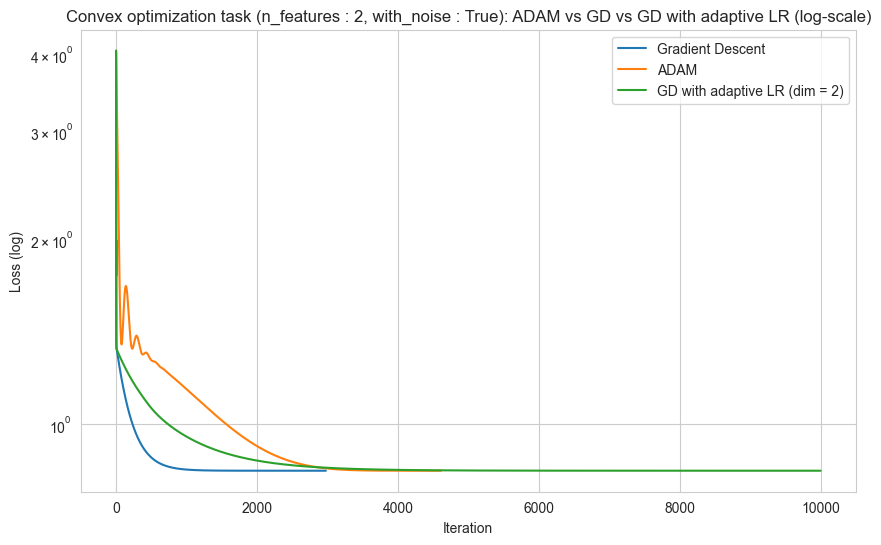

In [12]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(x=gd_it, y=gd_val, label='Gradient Descent')
sns.lineplot(x=adam_it, y=adam_val, label='ADAM')
sns.lineplot(x=rl_gd_it, y=rl_gd_val, label='GD with adaptive LR (dim = 2)')

plt.title('Convex optimization task (n_features : 2, with_noise : True): ADAM vs GD vs GD with adaptive LR (log-scale)')

plt.xlabel('Iteration')
plt.ylabel('Loss (log)')
plt.yscale('log')
plt.legend()

plt.show()